### **Automatic Detection**

#### **1. YOLOv8n**

In [14]:
!pip install ultralytics

In [19]:
from ultralytics import YOLO
from pathlib import Path
import pandas as pd


# 1. Load model
model = YOLO("yolov8n.pt")


# 2. Define paths
input_dir = Path(
    "/Users/xyz/Documents/PhD_Research/2026_04_CHR2027/03_webtoon_raw/window_veteran_of_the_apocalypse_episode1"
)


visual_output_dir = Path(
    "/Users/xyz/Documents/PhD_Research/2026_04_CHR2027/04_webtoon_results/character_detection"
)

csv_output_dir = Path(
    "/Users/xyz/Documents/PhD_Research/2026_04_CHR2027/02_data_results/character_detection"
)


visual_output_dir.mkdir(
    parents=True,
    exist_ok=True
)

csv_output_dir.mkdir(
    parents=True,
    exist_ok=True
)


# 3. Run YOLO
records = []

image_files = sorted(
    input_dir.glob("*.png")
)


print("Total windows:", len(image_files))


for img_path in image_files:

    print("Processing:", img_path.name)


    result = model(
        str(img_path),
        imgsz=1280,
        conf=0.25,
        classes=[0]   # only person
    )[0]


    # Save visualization

    plotted = result.plot()

    output_img = visual_output_dir / img_path.name

    from PIL import Image

    Image.fromarray(plotted).save(
        output_img
    )


    # Save bbox info

    for idx, box in enumerate(result.boxes):

        xyxy = box.xyxy[0].tolist()

        conf = float(box.conf[0])


        records.append({

            "window": img_path.name,

            "character_id": idx,

            "class": "person",

            "confidence": conf,

            "x1": xyxy[0],

            "y1": xyxy[1],

            "x2": xyxy[2],

            "y2": xyxy[3]

        })

# 4. Save CSV

df = pd.DataFrame(records)


csv_path = csv_output_dir / "character_detection_results.csv"


df.to_csv(
    csv_path,
    index=False
)


print("Finished!")
print("Detections:", len(df))
print("Saved:", csv_path)

Total windows: 89
Processing: window_001.png

image 1/1 /Users/xyz/Documents/PhD_Research/2026_04_CHR2027/03_webtoon_raw/window_veteran_of_the_apocalypse_episode1/window_001.png: 1280x320 1 person, 26.2ms
Speed: 1.6ms preprocess, 26.2ms inference, 0.4ms postprocess per image at shape (1, 3, 1280, 320)
Processing: window_002.png

image 1/1 /Users/xyz/Documents/PhD_Research/2026_04_CHR2027/03_webtoon_raw/window_veteran_of_the_apocalypse_episode1/window_002.png: 1280x320 2 persons, 24.3ms
Speed: 1.1ms preprocess, 24.3ms inference, 0.4ms postprocess per image at shape (1, 3, 1280, 320)
Processing: window_003.png

image 1/1 /Users/xyz/Documents/PhD_Research/2026_04_CHR2027/03_webtoon_raw/window_veteran_of_the_apocalypse_episode1/window_003.png: 1280x320 2 persons, 24.8ms
Speed: 1.1ms preprocess, 24.8ms inference, 0.4ms postprocess per image at shape (1, 3, 1280, 320)
Processing: window_004.png

image 1/1 /Users/xyz/Documents/PhD_Research/2026_04_CHR2027/03_webtoon_raw/window_veteran_of_the_

#### **2. ogkalu/comic-text-segmenter-yolov8m**

https://huggingface.co/ogkalu/comic-text-segmenter-yolov8m

In [1]:
from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
model_path = "../comic-speech-bubble-detector.pt"

model = YOLO(model_path)

In [3]:
print(model.names)

{0: 'text_bubble', 1: 'text_free'}


In [11]:
image_path = (
    "../03_webtoon_raw/window_i_will_marry_your_brother_episode1/window_037.png"
)


results = model(
    image_path,
    imgsz=1024,
    conf=0.25
)


image 1/1 /Users/xyz/Documents/PhD_Research/2026_04_CHR2027/codes/../03_webtoon_raw/window_i_will_marry_your_brother_episode1/window_037.png: 1024x256 2 text_frees, 103.5ms
Speed: 1.7ms preprocess, 103.5ms inference, 0.3ms postprocess per image at shape (1, 3, 1024, 256)


In [12]:
result = results[0]

print("detections:", len(result.boxes))

detections: 2


In [13]:
for box in result.boxes:

    conf = float(box.conf[0])

    cls = int(box.cls[0])

    print(
        model.names[cls],
        round(conf,3)
    )

text_free 0.731
text_free 0.401


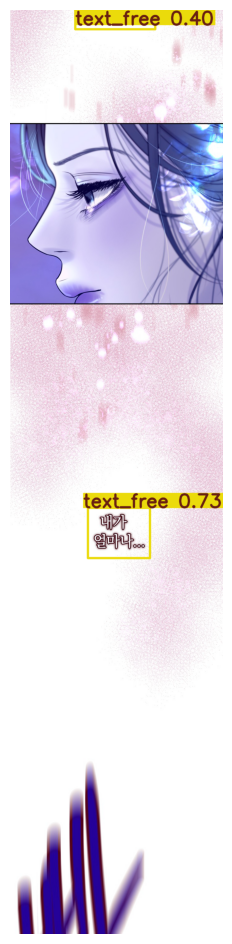

In [14]:
result_img = result.plot()


plt.figure(figsize=(8,12))
plt.imshow(result_img)
plt.axis("off")
plt.show()

In [17]:
from ultralytics import YOLO
from pathlib import Path
import pandas as pd
from PIL import Image

# 1. Load model

model_path = "../comic-speech-bubble-detector.pt"
model = YOLO(model_path)

print(model.names)
# expected:
# {0: 'text_bubble', 1: 'text_free'}


# 2. Paths

input_dir = Path(
    "../03_webtoon_raw/window_veteran_of_the_apocalypse_episode1"
)

visual_output_dir = Path(
    "../04_webtoon_results/text_veteran_of_the_apocalypse_episode1"
)

csv_output_dir = Path(
    "../02_data_results/text_region_detection"
)

visual_output_dir.mkdir(
    parents=True,
    exist_ok=True
)

csv_output_dir.mkdir(
    parents=True,
    exist_ok=True
)


# 3. Get all windows

image_files = sorted(input_dir.glob("window_*.png"))

print("Total windows:", len(image_files))


# 4. Run detection

records = []

for img_path in image_files:

    print("Processing:", img_path.name)

    result = model(
        str(img_path),
        imgsz=1024,
        conf=0.25
    )[0]

    # Save detected image

    plotted = result.plot()

    output_image_path = (
        visual_output_dir / img_path.name
    )

    Image.fromarray(plotted).save(
        output_image_path
    )


    # Save detection data

    for detection_id, box in enumerate(result.boxes, start=1):

        cls = int(box.cls[0])
        label = model.names[cls]

        conf = float(box.conf[0])

        x1, y1, x2, y2 = box.xyxy[0].tolist()

        records.append({
            "window": img_path.name,
            "detection_id": detection_id,
            "label": label,
            "confidence": conf,
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2
        })


# 5. Save CSV

df = pd.DataFrame(records)

csv_path = (
    csv_output_dir
    / "text_veteran_of_the_apocalypse_episode1.csv"
)

df.to_csv(
    csv_path,
    index=False
)


# 6. Summary

print("\nFinished!")
print("Total detections:", len(df))

if len(df) > 0:
    print("\nDetections by class:")
    print(df["label"].value_counts())

print("\nImages saved to:")
print(visual_output_dir)

print("\nCSV saved to:")
print(csv_path)

{0: 'text_bubble', 1: 'text_free'}
Total windows: 89
Processing: window_001.png

image 1/1 /Users/xyz/Documents/PhD_Research/2026_04_CHR2027/codes/../03_webtoon_raw/window_veteran_of_the_apocalypse_episode1/window_001.png: 1024x256 2 text_bubbles, 94.5ms
Speed: 1.0ms preprocess, 94.5ms inference, 0.2ms postprocess per image at shape (1, 3, 1024, 256)
Processing: window_002.png

image 1/1 /Users/xyz/Documents/PhD_Research/2026_04_CHR2027/codes/../03_webtoon_raw/window_veteran_of_the_apocalypse_episode1/window_002.png: 1024x256 2 text_bubbles, 92.9ms
Speed: 1.0ms preprocess, 92.9ms inference, 0.3ms postprocess per image at shape (1, 3, 1024, 256)
Processing: window_003.png

image 1/1 /Users/xyz/Documents/PhD_Research/2026_04_CHR2027/codes/../03_webtoon_raw/window_veteran_of_the_apocalypse_episode1/window_003.png: 1024x256 3 text_bubbles, 91.2ms
Speed: 1.0ms preprocess, 91.2ms inference, 0.3ms postprocess per image at shape (1, 3, 1024, 256)
Processing: window_004.png

image 1/1 /Users/xy

#### **3. best-comic-panel-detection**

https://huggingface.co/mosesb/best-comic-panel-detection/tree/main

In [39]:
from ultralytics import YOLO
from pathlib import Path
import pandas as pd
import cv2


# 1. Paths

input_dir = Path(
    "../03_webtoon_raw/window_veteran_of_the_apocalypse_episode1"
)

output_image_dir = Path(
    "../03_webtoon_raw/panel_detection_images"
)

output_csv_dir = Path(
    "../03_webtoon_raw/panel_detection_csv"
)

output_image_dir.mkdir(parents=True, exist_ok=True)
output_csv_dir.mkdir(parents=True, exist_ok=True)


# 2. Load model

model = YOLO("best.pt")


# 3. Find all images

image_extensions = {".png", ".jpg", ".jpeg", ".webp"}

image_paths = sorted(
    [
        p for p in input_dir.iterdir()
        if p.suffix.lower() in image_extensions
    ]
)

print(f"Found {len(image_paths)} images.")


# 4. Store detection results

all_detections = []


# 5. Run panel detection

for image_index, image_path in enumerate(image_paths, start=1):

    print(
        f"[{image_index}/{len(image_paths)}] "
        f"Processing {image_path.name}"
    )

    
    # YOLO prediction
    results = model.predict(
        source=str(image_path),
        imgsz=640,
        conf=0.25,
        verbose=False
    )

    result = results[0]

    # Save visualization

    plotted_image = result.plot()

    output_image_path = (
        output_image_dir / image_path.name
    )

    cv2.imwrite(
        str(output_image_path),
        plotted_image
    )

    # Save detection coordinates

    if result.boxes is not None:

        boxes = result.boxes

        for panel_id, box in enumerate(boxes, start=1):

            xyxy = box.xyxy[0].cpu().numpy()

            x1, y1, x2, y2 = xyxy

            confidence = float(
                box.conf[0].cpu().numpy()
            )

            all_detections.append(
                {
                    "image": image_path.name,
                    "panel_id": panel_id,
                    "confidence": confidence,
                    "x1": float(x1),
                    "y1": float(y1),
                    "x2": float(x2),
                    "y2": float(y2)
                }
            )

    print(
        f"    detected panels: {len(result.boxes)}"
        if result.boxes is not None
        else "    detected panels: 0"
    )


# 6. Save CSV

df = pd.DataFrame(all_detections)

csv_path = (
    output_csv_dir / "panel_detections.csv"
)

df.to_csv(
    csv_path,
    index=False
)


# 7. Summary

print("\n" + "=" * 60)

print("Finished!")

print(f"Images processed: {len(image_paths)}")
print(f"Panels detected: {len(df)}")

print("\nDetection images:")
print(output_image_dir)

print("\nCSV:")
print(csv_path)

print("=" * 60)

Found 89 images.
[1/89] Processing window_001.png
    detected panels: 1
[2/89] Processing window_002.png
    detected panels: 3
[3/89] Processing window_003.png
    detected panels: 2
[4/89] Processing window_004.png
    detected panels: 1
[5/89] Processing window_005.png
    detected panels: 3
[6/89] Processing window_006.png
    detected panels: 0
[7/89] Processing window_007.png
    detected panels: 2
[8/89] Processing window_008.png
    detected panels: 3
[9/89] Processing window_009.png
    detected panels: 5
[10/89] Processing window_010.png
    detected panels: 2
[11/89] Processing window_011.png
    detected panels: 1
[12/89] Processing window_012.png
    detected panels: 1
[13/89] Processing window_013.png
    detected panels: 0
[14/89] Processing window_014.png
    detected panels: 1
[15/89] Processing window_015.png
    detected panels: 2
[16/89] Processing window_016.png
    detected panels: 3
[17/89] Processing window_017.png
    detected panels: 2
[18/89] Processing wind